Prototipo Projeto CAR

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from load_data import GeoDataLoader

#carrega dados
arquivos = {
        "car": "dados/PARA/CAR/AREA_IMOVEL_1.shp",
        "municipios": "dados/PARA/Municipios/PA_Municipios_2023.shp",
        "uf": "dados/PARA/UF/PA_UF_2023.shp",
        "UCs": "dados/PARA/UCs/cat60_protected_area_WGS84_v2.shp",
       "Overlaps":"Resultados/car_car_intersect/shapes_intersect.shp",

        "Assen.": "dados/PARA/Assentamentos/cat63_settlements_WGS84.shp",
       "Quil.": "dados/PARA/Quilombolas/cat62_quilombola_WGS84.shp",
       
       
        "Agua": "dados/PARA/Agua/geoft_bho_massa_dagua_v2019.shp",
    
       "TIs": "dados/PARA/TIs/cat61_indigenous_territories_WGS84.shp",
}


datasets = GeoDataLoader().load_all(arquivos)

gdf,g_m,uf=datasets["car"],datasets["municipios"],datasets["uf"]



print(datasets.keys())




Loading car from dados/PARA/CAR/AREA_IMOVEL_1.shp...
No 'codigo' column found in the shapefile.
No 'codigo' column found in the shapefile.
Loading municipios from dados/PARA/Municipios/PA_Municipios_2023.shp...
No 'codigo' column found in the shapefile.
No 'codigo' column found in the shapefile.
Loading uf from dados/PARA/UF/PA_UF_2023.shp...
No 'codigo' column found in the shapefile.
No 'codigo' column found in the shapefile.
Loading UCs from dados/PARA/UCs/cat60_protected_area_WGS84_v2.shp...
No 'codigo' column found in the shapefile.
No 'codigo' column found in the shapefile.
Loading Overlaps from Resultados/car_car_intersect/shapes_intersect.shp...
No 'codigo' column found in the shapefile.
No 'codigo' column found in the shapefile.
Loading Assen. from dados/PARA/Assentamentos/cat63_settlements_WGS84.shp...
No 'codigo' column found in the shapefile.
No 'codigo' column found in the shapefile.
Loading Quil. from dados/PARA/Quilombolas/cat62_quilombola_WGS84.shp...
No 'codigo' column 

In [2]:
# Load the result CSV and input CSV
result_csv_path = "Resultados/resultados_por_car.csv"  # Replace with your result CSV file path
input_csv_path = "Resultados/input.csv"    # Replace with your input CSV file path


# Read the CSV files (adjust settings if necessary)
input_df = pd.read_csv(input_csv_path, sep=';', skiprows=5, encoding='latin1', on_bad_lines='skip')
result_df = pd.read_csv(result_csv_path)

# Ensure the input and result columns are named properly
input_df.columns = input_df.columns.str.strip()  # Clean up column names
result_df.columns = result_df.columns.str.strip()
print(input_df.head())
# Match the first column of input with the CAR column in the result
input_first_column = input_df.iloc[:, 0]  # First column of input
result_first_column = result_df.iloc[:, 0]  # First column of result

print("Input first column:")
print(input_first_column)
print("Result first column:")
print(result_first_column)
matched_rows = result_df[result_first_column.isin(input_first_column)]

# Display the matched rows
print("Matched rows:")
print(matched_rows)

# Save the matched rows to a new CSV file
matched_rows.to_csv("matched_rows.csv", index=True)


car_list=matched_rows.iloc[:, 0].tolist()

print(gdf.head())

NameError: name 'pd' is not defined

In [3]:
import os
import geopandas as gpd
import pandas as pd

# Define the base directory containing the intersection folders
base_dir = "Resultados"
intersect_dict = {
        "UCs_intersect": "Resultados/UCs_intersect/shapes_intersect.shp",
        "car_car_intersect": "Resultados/car_car_intersect/shapes_intersect.shp",
        "TIs_intersect": "Resultados/TIs_intersect/shapes_intersect.shp",
        "Quil._intersect": "Resultados/Quil._intersect/shapes_intersect.shp",
        "Agua_intersect": "Resultados/Agua_intersect/shapes_intersect.shp",
        "Assen._intersect": "Resultados/Assen._intersect/shapes_intersect.shp",
}
# Initialize an empty list to store GeoDataFrames
intersecting_gdfs = []
names=[]
# Iterate through each folder in the base directory
for key,folder_name in intersect_dict.items():
    if key == "car_car_intersect":
        # Skip the "car_car_intersect" folder
        continue
    print(folder_name)
    if True:
        # Load the intersection data from the folder
        shapefile_path= folder_name
        if os.path.exists(shapefile_path):
            intersecting_gdf = gpd.read_file(shapefile_path)
          #  print(intersecting_gdf.head())
            # Match CAR IDs from the intersecting set with the loaded CAR set to get CAR status
            intersecting_gdf = intersecting_gdf.merge(
                gdf[['cod_imovel', 'des_condic']], 
                left_on="property_i", 
                right_on="cod_imovel", 
                how="left"
)
            intersecting_gdf["des_condic"]= intersecting_gdf['des_condic'].apply(
            lambda x: "Analisado" if x.startswith("Analisado") else (
                "Cancelado" if x.startswith("Cancelado") else "Em analise"
            )
)
         #   print("aaaaaa",key[:-10])
            key=key[:-10]
            datasets[key].rename(columns={datasets[key].columns[0]: 'id'}, inplace=True)

        #    print(datasets[key].head())
        
            intersecting_gdf = intersecting_gdf.merge(
                        datasets[key], 
                        left_on="uc_id", 
                        right_on="id", 
                        how="left"
                    )
            
            names.append(key)
            intersecting_gdfs.append(intersecting_gdf)
        



shapefile_path = intersect_dict["car_car_intersect"]
if os.path.exists(shapefile_path):
    intersecting_gdf = gpd.read_file(shapefile_path)
    print(intersecting_gdf.head())

    # Merge to get CAR status information
    intersecting_gdf = intersecting_gdf.merge(
        gdf[['cod_imovel', 'des_condic']], 
        left_on="property_i", 
        right_on="cod_imovel", 
        how="left"
    )
    intersecting_gdf["des_condic"] = intersecting_gdf['des_condic'].apply(
        lambda x: "Analisado" if x.startswith("Analisado") else (
            "Cancelado" if x.startswith("Cancelado") else "Em analise"
        )
    )

    # Rename first column to 'id' for consistency
    key = "car"  # Use a specific key for the car_car dataset
    if key in datasets:
        datasets[key].rename(columns={datasets[key].columns[0]: 'id'}, inplace=True)
       # print(datasets[key].head())

        # Merge the intersection data with the UC dataset based on 'id'
        intersecting_gdf = intersecting_gdf.merge(
            datasets[key], 
            left_on="uc_i", 
            right_on="cod_imovel", 
            how="left"
        )

        names.append(key)
        intersecting_gdfs.append(intersecting_gdf)
        print(intersecting_gdf.head())


sets=[datasets["UCs"],datasets["car"],datasets["TIs"],datasets["Quil."],datasets["Agua"]]

Resultados/UCs_intersect/shapes_intersect.shp
Resultados/TIs_intersect/shapes_intersect.shp
Resultados/Quil._intersect/shapes_intersect.shp
Resultados/Agua_intersect/shapes_intersect.shp
Resultados/Assen._intersect/shapes_intersect.shp
                                    property_i  \
0  PA-1500503-1B415D59863B470E9EFB4BE2F150E6D7   
1  PA-1500503-1B415D59863B470E9EFB4BE2F150E6D7   
2  PA-1500503-1B415D59863B470E9EFB4BE2F150E6D7   
3  PA-1500503-1B415D59863B470E9EFB4BE2F150E6D7   
4  PA-1500503-1B415D59863B470E9EFB4BE2F150E6D7   

                                          uc_i  \
0  PA-1500503-9BCDEF19835F4A709056FCBC709847B2   
1  PA-1500503-430FACD5D84F4C8591B17BBBFCB94A80   
2  PA-1500503-D813D36188744EC5918FC84D4F56653A   
3  PA-1500503-8E9DFB93B2E441ACA1FB85E312C00178   
4  PA-1500503-9B5290399E79475A92960604141F01F3   

                                            geometry  
0  POLYGON ((-51.992 -1.4068, -52.0061 -1.4107, -...  
1  POLYGON ((-52.1336 -1.2866, -52.1151 -1.2859, ...

In [136]:
# Dictionary to store intersections for each CAR
intersections_by_car = {}

# Open the output file in write mode
with open("intersections_output.txt", "w") as output_file:

    # Iterate through each CAR in the selected list
    for idx, car_row in matched_rows.iterrows():
        car_id = car_row["CAR"]  # Assuming 'cod_imovel' is the unique CAR ID
        output_file.write(f"\n-------------------------------Interseções para o CAR ID: {car_id} ( {car_row['cond']})-------------------------------\n")
        
        # Initialize an empty dictionary to store intersections for this CAR
        intersections_by_car[car_id] = {}
        found_intersections = False  # Flag to track if any intersections are found for this CAR
        
        # Iterate through each dataset in datasets
        for dset, data in zip(names, intersecting_gdfs):
            data["geometry"] = data["geometry_x"]
            
            # Filter the dataset for intersections with the current CAR
            intersecting = data[data["property_i"] == car_id].copy()
            
            if not intersecting.empty:
                found_intersections = True  # Mark that we've found intersections
                
                # Store the intersecting records
                intersections_by_car[car_id][dset] = intersecting[["cod_imovel", "geometry"]]
                output_file.write(f"\n  ** Encontradas {len(intersecting)} interseções com o dataset: {dset} **\n")
                
                # Loop through intersecting rows and write them clearly to the file
                for _, row in intersecting.iterrows():
                    area_in_m2 = car_row["Área_Total"]  # Assuming this is the area calculation in meters
                    output_file.write(f"    - Nome {dset}: {row['name']}\n")
                    output_file.write(f"      Área do CAR: {area_in_m2:.2f} ha\n")
                    output_file.write(f"      Área Intersectada: {row['intersecti'] * 111 * 110.8:.2f} ha\n")
                    output_file.write(f"    -------------------------------\n")  # Separator for each intersection
        
        # If no intersections are found for the current CAR, write a warning
        if not found_intersections:
            output_file.write(f"\n  ** Nenhuma interseção encontrada para o CAR {car_id}. **\n")
            output_file.write(f"  -------------------------------\n")
        
        output_file.write("\n\n\n")







UCs


/tmp/ipykernel_2375840/3975700185.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  total_area = sets[row_idx].geometry.area.sum()


AttributeError: You are calling a geospatial method on the GeoDataFrame, but the active geometry column ('geometry') is not present. 
There are columns with geometry data type (['geometry_x', 'geometry_y']), and you can either set one as the active geometry with df.set_geometry("name") or access the column as a GeoSeries (df["name"]) and call the method directly on it.

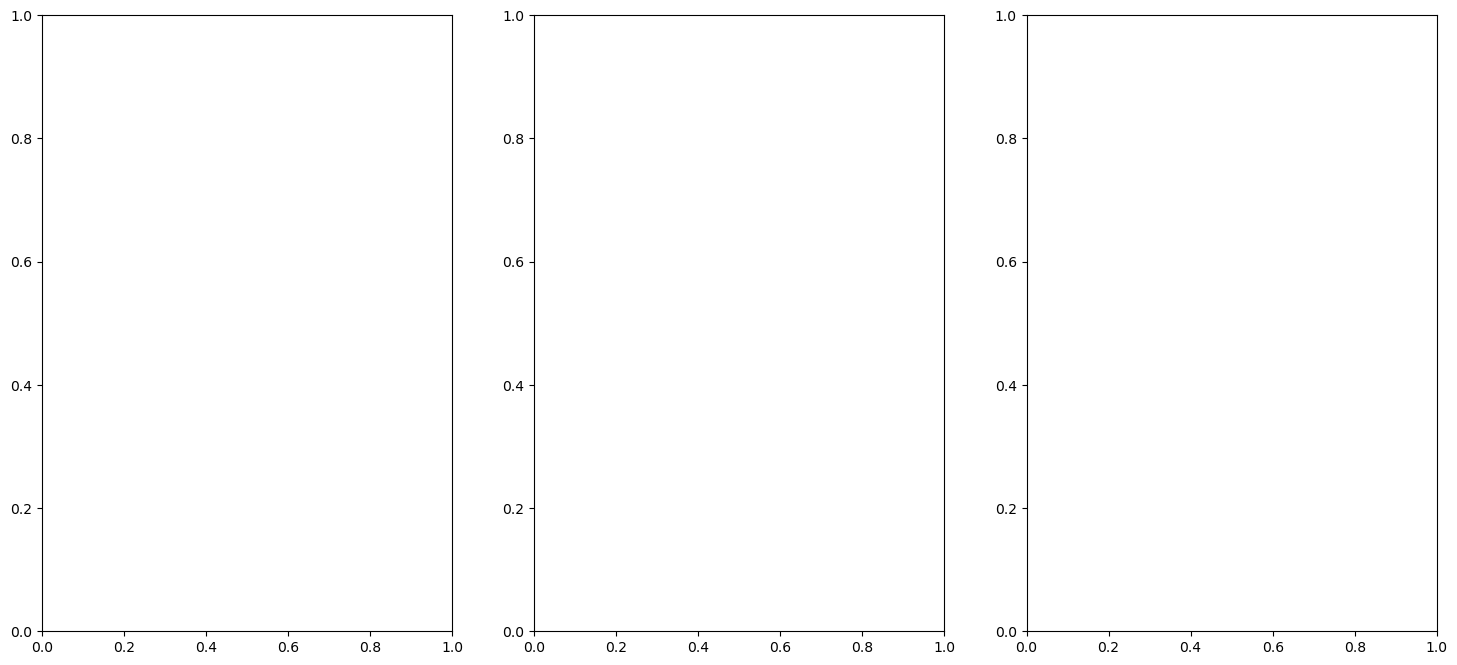

In [131]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Standardize and sort the `des_condic` column for CAR geometries
gdf['des_condic'] = gdf['des_condic'].apply(
    lambda x: "Analisado" if x.startswith("Analisado") else (
        "Cancelado" if x.startswith("Cancelado") else "Em analise"
    )
)


# Subset the intersecting GeoDataFrames to the first few
intersecting_gdfs = intersecting_gdfs[:5]

# Get all unique statuses
unique_statuses = sorted(gdf['des_condic'].unique())

# Iterate over each intersecting GeoDataFrame to create separate figures
for row_idx, intersecting_gdf in enumerate(intersecting_gdfs):
    print(names[row_idx])
    # Skip the 'car_car_intersect' set

    fig_width = max(12, len(unique_statuses) * 6)
    fig_height = 8  # Set a fixed height for consistency


    # Calculate total area of the relevant set
    total_area = sets[row_idx].geometry.area.sum()

    # Initialize intersection area for the category
    intersection_area = 0

    # Create a figure with subplots for each status
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(unique_statuses),
        figsize=(fig_width, fig_height),
    )

    # Ensure axes is iterable even for a single status
    if len(unique_statuses) == 1:
        axes = [axes]

    # Iterate over statuses for columns
    for col_idx, status in enumerate(unique_statuses):
        ax = axes[col_idx]
        # Filter the GeoDataFrame by the current status
        filtered_gdf = intersecting_gdf[intersecting_gdf["des_condic"] == status]

        # Accumulate the intersection area
        intersection_area += filtered_gdf.geometry.area.sum()

        if not filtered_gdf.empty:
            # Plot UF boundaries
            uf.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=0.5, label='UF')

            # Plot city boundaries
            g_m.plot(ax=ax, color='white', edgecolor='grey', linewidth=0.5, alpha=0.7, label='Cities')
            gdf[gdf["des_condic"] == status].plot(ax=ax, color='green', edgecolor='black', linewidth=0.005, alpha=0.4, label='CAR')
            # Plot the relevant set geometry
            if(names[row_idx] != "car_car_intersect"):
                sets[row_idx].plot(ax=ax, color='blue', alpha=0.5, label='CAR')
            

            # Plot the filtered GeoDataFrame
            filtered_gdf.plot(ax=ax, color='red', alpha=0.8, label=f"Status: {status}")

            # Set title for the subplot
            ax.set_title(f"Intersection Map: {status}", fontsize=12)

        else:
            # If no data, set an empty plot with a message
            ax.text(0.5, 0.5, "No Data", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
            ax.set_title(f"No Intersection for Status: {status}", fontsize=12)

        # Remove axis ticks for cleaner visualization
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylim(uf.total_bounds[1], uf.total_bounds[3])
        ax.set_xlim(uf.total_bounds[0], uf.total_bounds[2])

        # Add legend for the first subplot in each figure
        if col_idx == 0:
            ax.legend(loc="upper left", fontsize=10)


    # Tighten layout to minimize white space
    plt.tight_layout()

    # Save or display the figure
    plt.savefig(f"intersection_map_row_{row_idx + 1}.png", dpi=300)
    plt.show()


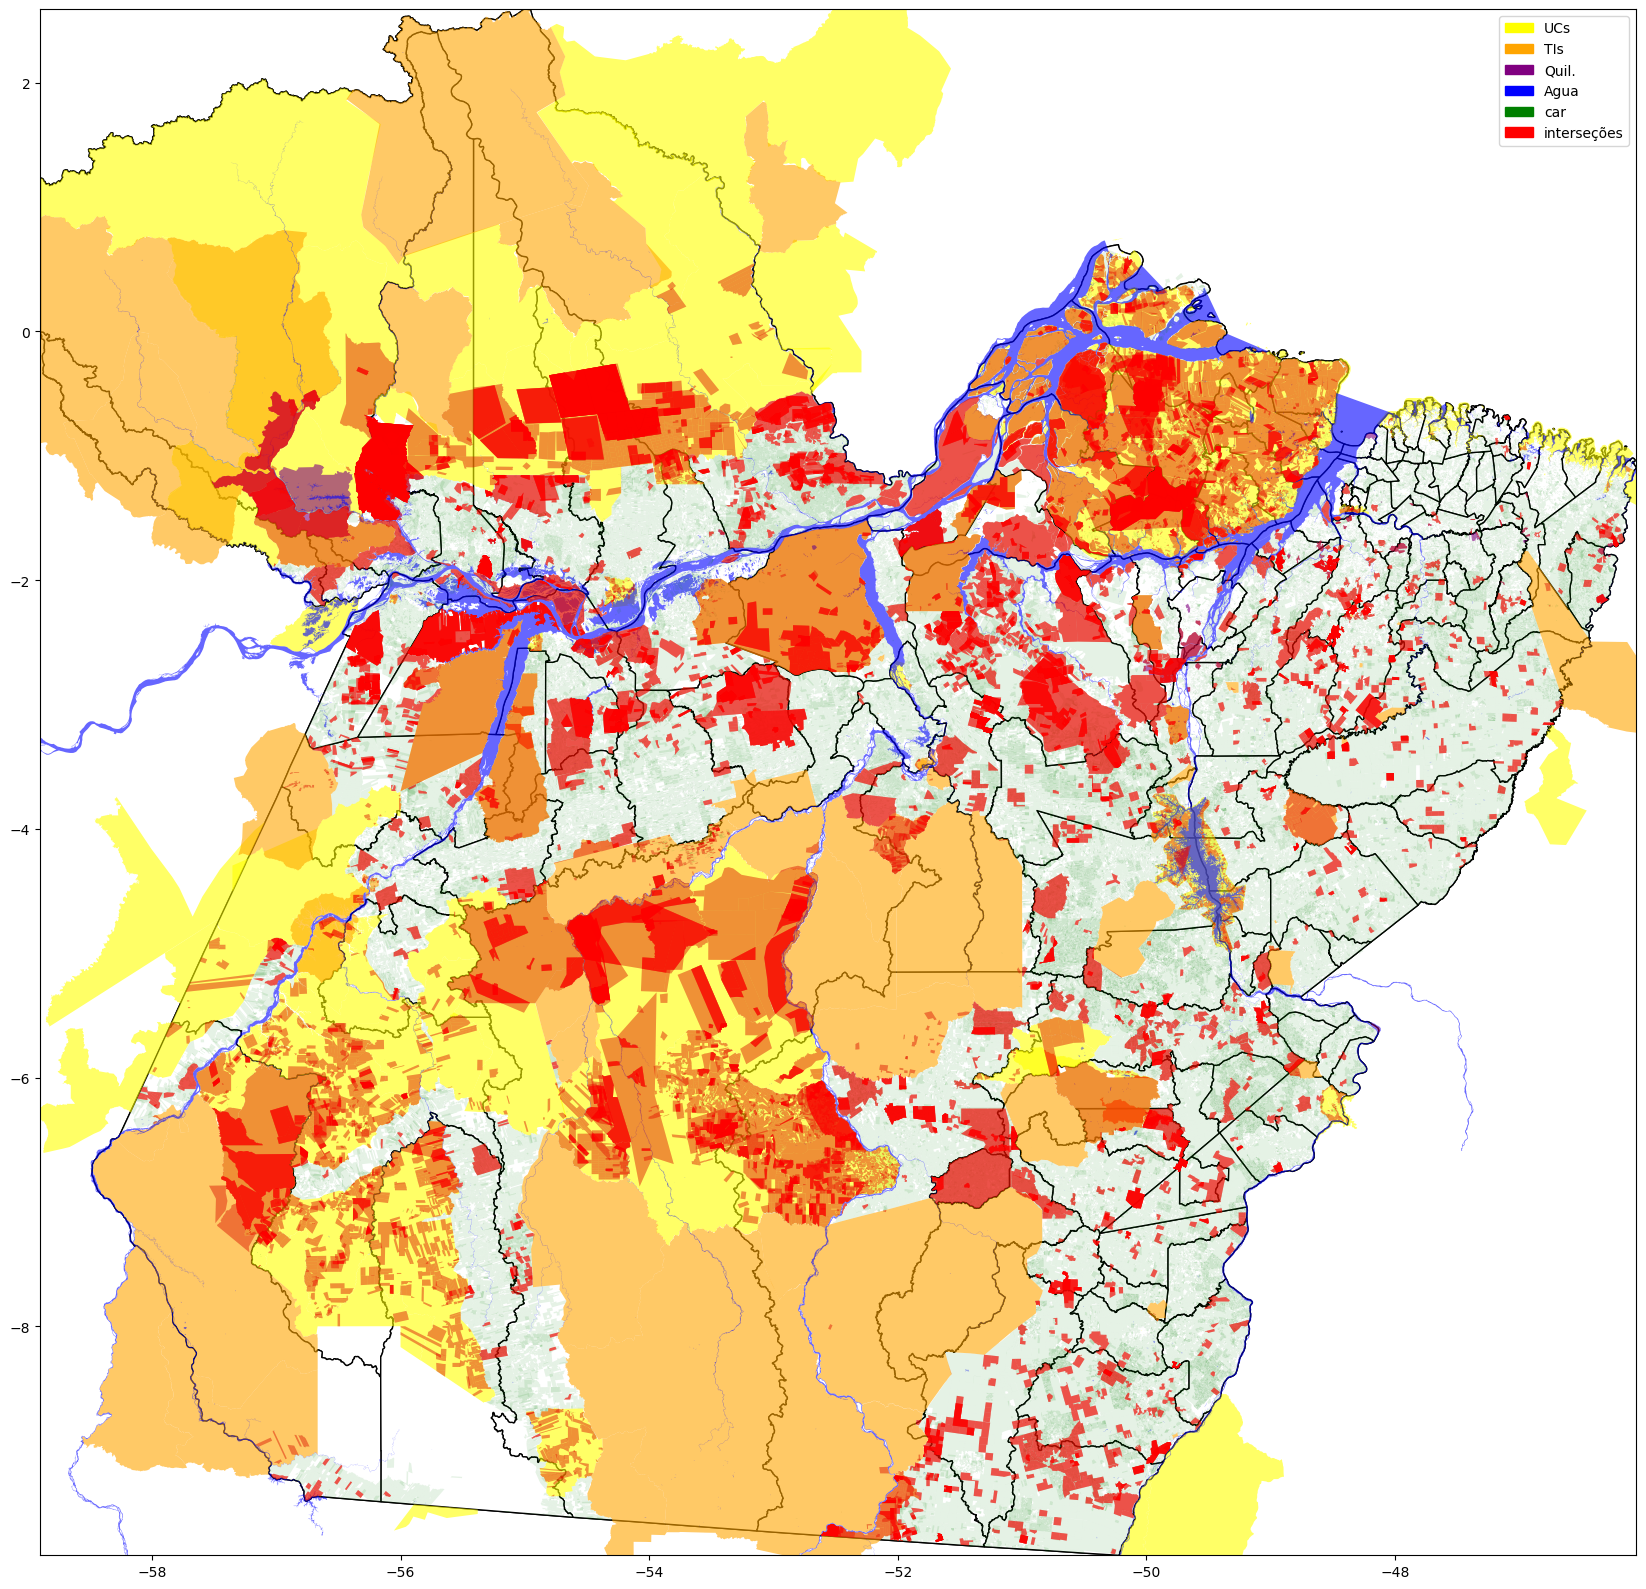

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Assuming these variables are already defined:
# q_is: List of datasets (like categories of data)
# datasets: Dictionary where each dataset is stored (each corresponding to a key in q_is)
# uf, municipios, car, intersect: GeoDataFrames for plotting
# cores: List of colors corresponding to each dataset
car=gdf
i = 0  # Index for accessing colors

q_is = ["UCs", "TIs", "Quil.", "Agua"]  # List of datasets to plot
cores= ['yellow', 'orange', 'purple', 'blue']  # List of colors for each dataset
fig, ax = plt.subplots(figsize=(30, 16), dpi=100)
    # Plot the base maps: States (uf) and Municipalities (municipios)
uf.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)
g_m.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)

    # Initialize a list for storing legend proxies
proxy_artists = []
    # Plot the dataset (dset) with the corresponding color
for i,dset in enumerate(q_is):
    # Create a new figure and axis
    datasets[dset].plot(ax=ax, edgecolor='black', linewidth=0, color=cores[i], alpha=0.6)    

    

            # Plot intersections (red color)

    
    
    
    proxy = mpatches.Patch(color=cores[i], label=dset)  # Create a legend patch for this dataset
    proxy_artists.append(proxy)
    

    # Plot the CAR data (green color)
car_plot_obj = car.plot(ax=ax, color='green', edgecolor='black', linewidth=0.00001, alpha=0.1)
car_proxy = mpatches.Patch(color='green', label='car')  # Add a legend for CAR data
proxy_artists.append(car_proxy)
for i,dset in enumerate(q_is):
    intersect=intersecting_gdfs[i]
    i_obj = intersect.plot(ax=ax, color='red', edgecolor='black', linewidth=0.0001, alpha=0.4)
    i_proxy = mpatches.Patch(color='red', label='interseções')  # Add a legend for intersections

proxy_artists.append(i_proxy)
  # Add the legend to the plot
ax.legend(handles=proxy_artists)
ax.set_ylim(uf.total_bounds[1], uf.total_bounds[3])
ax.set_xlim(uf.total_bounds[0], uf.total_bounds[2])

    # Adjust the layout to avoid overlap
plt.tight_layout()


plt.show()
    # Close the figure to free memory
plt.close()


                                    property_i         uc_id  intersecti  \
0  PA-1500503-19C8BC4DC0E240539194219663BDCFF1  0000.00.0067    0.000187   
1  PA-1500503-46AB8910852449A98F06624E1E71B5FA  0000.00.0067    0.000224   
2  PA-1500503-4E9733D77054479B9CF019748117C251  0000.00.0067    0.000194   
3  PA-1500503-AB02627E34E04BF8BAC2F93B87BA744A  0000.00.0067    0.012330   
4  PA-1500503-1F7A7E9415D848449F33C83929B742E1  0000.00.0067    0.002349   

   overlap_ar                                           geometry  \
0    0.000187  POLYGON ((-52.90082 -0.52911, -52.90338 -0.517...   
1    0.000224  POLYGON ((-53.15803 -0.76515, -53.15868 -0.766...   
2    0.000194  POLYGON ((-53.1595 -0.76853, -53.16043 -0.7702...   
3    0.012330  POLYGON ((-53.13818 -0.70302, -53.13752 -0.703...   
4    0.002349  POLYGON ((-53.28416 -0.72251, -53.28409 -0.722...   

                                    cod_imovel  des_condic  
0  PA-1500503-19C8BC4DC0E240539194219663BDCFF1  Em analise  
1  PA-150050

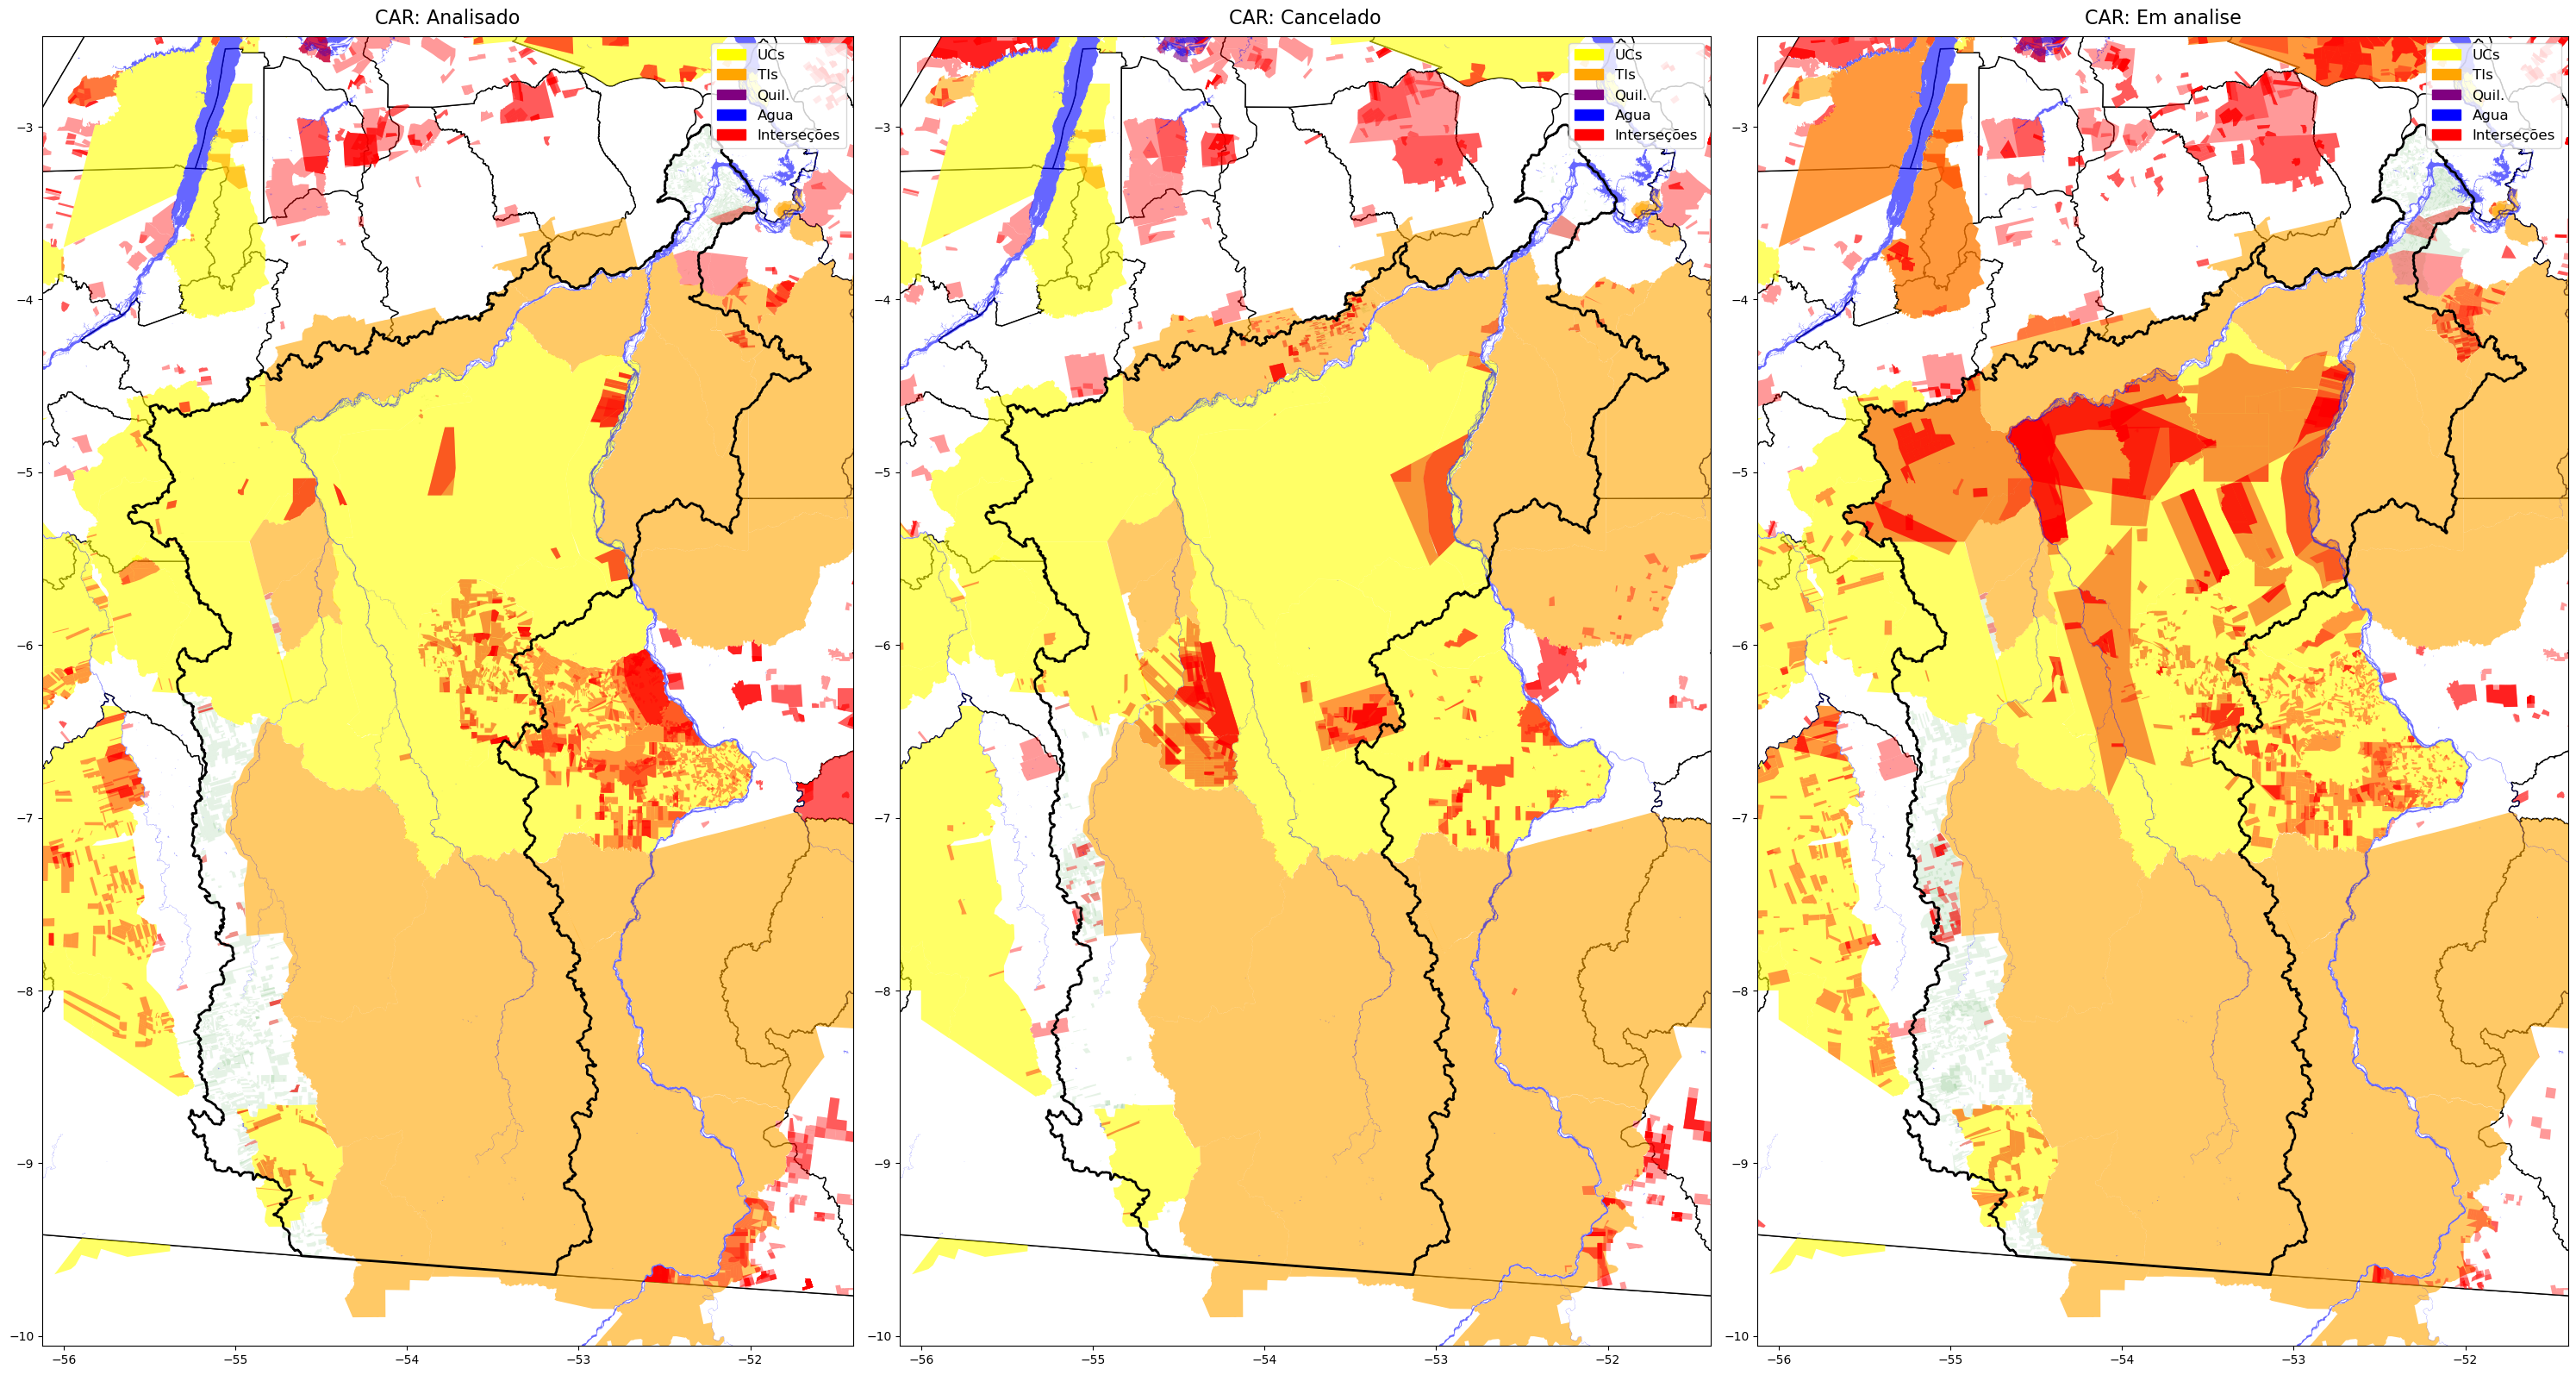

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

car = gdf  # Assuming car is the GeoDataFrame containing the CAR data

print(intersecting_gdfs[0].head())
# Create a new column for condition description
car["desc_cond"] = car['des_condic'].apply(
    lambda x: "Analisado" if x.startswith("Analisado") else (
        "Cancelado" if x.startswith("Cancelado") else "Em analise"
    )
)

# Assuming these variables are already defined:
# car: The CAR GeoDataFrame (gdf or car)
# uf, municipios: GeoDataFrames for base plotting
# intersecting_gdfs: GeoDataFrame with intersection data
# q_is: List of datasets to plot (UCs, TIs, Quil., Agua)
# datasets: Dictionary where each dataset is stored (corresponding to keys in q_is)
# cores: List of colors corresponding to each dataset

# Filter CAR data for Altamira (adjust if needed based on the correct column name)
altamira_car = car[car['municipio'].str.contains('altamira', case=False, na=False)]

# Coordinates for Altamira (get bounds of the filtered CAR data)
minx, miny, maxx, maxy = altamira_car.total_bounds

# Define CAR categories
conditions = ['Analisado', 'Cancelado', 'Em analise']

# Create a subplot grid: 1 row and 3 columns (one for each condition)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(30, 16), dpi=100)

# Initialize a list for storing legend proxies
proxy_artists = []

# Loop through each condition and plot
for i, cond in enumerate(conditions):
    ax = axes[i]  # Access the subplot for the condition
    
    # Plot the base maps: States (uf) and Municipalities (municipios)
    uf.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)
    g_m.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)
    
    # Plot the filtered CAR data for the current condition
    condition_car = altamira_car[altamira_car['desc_cond'] == cond]  # Filter for the condition
    condition_car.plot(ax=ax, color='green', edgecolor='black', linewidth=0.00001, alpha=0.1)

    # Plot each dataset (dset) with corresponding colors
    for j, dset in enumerate(q_is):
        datasets[dset].plot(ax=ax, edgecolor='black', linewidth=0, color=cores[j], alpha=0.6)
        proxy = mpatches.Patch(color=cores[j], label=dset)  # Create a legend patch for this dataset
        proxy_artists.append(proxy)
    
        # Filter intersections based on the current condition
        condition_intersect = intersecting_gdfs[j][intersecting_gdfs[j]['des_condic'] == cond]
        condition_intersect.plot(ax=ax, color='red', edgecolor='black', linewidth=0.0001, alpha=0.4)
        i_proxy = mpatches.Patch(color='red', label='Interseções')  # Add a legend for intersections
    proxy_artists.append(i_proxy)

    # Plot the boundaries of Altamira with a darker color and thicker line
    altamira = g_m[g_m['NM_MUN'].str.contains('altamira', case=False, na=False)]  # Filter Altamira from municipios
    altamira.plot(ax=ax, edgecolor='black', linewidth=2, facecolor='none')  # Darker line for Altamira
    
    # Set title for each subplot (condition)
    ax.set_title(f"CAR: {cond}", fontsize=16, pad=10)
    
    # Set the limits for each subplot (centered around Altamira)
    ax.set_xlim(minx - 0.5, maxx + 0.5)
    ax.set_ylim(miny - 0.5, maxy + 0.5)
    
    # Add the legend to the plot for each subplot
    ax.legend(handles=proxy_artists, loc='upper right', fontsize=12)
    proxy_artists = []  
# Adjust the layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()

# Close the figure to free memory
plt.close()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

car = gdf  # Assuming car is the GeoDataFrame containing the CAR data

# Create a new column for condition description
car["desc_cond"] = car['des_condic'].apply(
    lambda x: "Analisado" if x.startswith("Analisado") else (
        "Cancelado" if x.startswith("Cancelado") else "Em analise"
    )
)

# Filter CAR data for Tucuruí (adjust if needed based on the correct column name)
tucurui_car = car[car['municipio'].str.contains('tucuruí', case=False, na=False)]

# Coordinates for Tucuruí (get bounds of the filtered CAR data)
minx, miny, maxx, maxy = tucurui_car.total_bounds

# Define CAR categories
conditions = ['Analisado', 'Cancelado', 'Em analise']

# Create a subplot grid: 1 row and 3 columns (one for each condition)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(30, 16), dpi=100)

# Initialize a list for storing legend proxies
proxy_artists = []

# Loop through each condition and plot
for i, cond in enumerate(conditions):
    ax = axes[i]  # Access the subplot for the condition
    
    # Plot the base maps: States (uf) and Municipalities (municipios)
    uf.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)
    g_m.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)
    
    # Plot the filtered CAR data for the current condition
    condition_car = tucurui_car[tucurui_car['desc_cond'] == cond]  # Filter for the condition
    condition_car.plot(ax=ax, color='green', edgecolor='black', linewidth=0.00001, alpha=0.1)

    # Plot each dataset (dset) with corresponding colors
    for j, dset in enumerate(q_is):
        datasets[dset].plot(ax=ax, edgecolor='black', linewidth=0, color=cores[j], alpha=0.6)
        proxy = mpatches.Patch(color=cores[j], label=dset)  # Create a legend patch for this dataset
        proxy_artists.append(proxy)
    
        # Filter intersections based on the current condition
        condition_intersect = intersecting_gdfs[j][intersecting_gdfs[j]['des_condic'] == cond]
        condition_intersect.plot(ax=ax, color='red', edgecolor='black', linewidth=0.0001, alpha=0.4)
        i_proxy = mpatches.Patch(color='red', label='Interseções')  # Add a legend for intersections
    proxy_artists.append(i_proxy)

    # Plot the boundaries of Tucuruí with a darker color and thicker line
    tucurui = g_m[g_m['NM_MUN'].str.contains('tucuruí', case=False, na=False)]  # Filter Tucuruí from municipios
    tucurui.plot(ax=ax, edgecolor='black', linewidth=2, facecolor='none')  # Darker line for Tucuruí
    
    # Set title for each subplot (condition)
    ax.set_title(f"CAR: {cond}", fontsize=16, pad=10)
    
    # Set the limits for each subplot (centered around Tucuruí)
    ax.set_xlim(minx - 0.5, maxx + 0.5)
    ax.set_ylim(miny - 0.5, maxy + 0.5)
    
    # Add the legend to the plot for each subplot
    ax.legend(handles=proxy_artists, loc='upper right', fontsize=12)
    proxy_artists = []  
# Adjust the layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()

# Close the figure to free memory
plt.close()


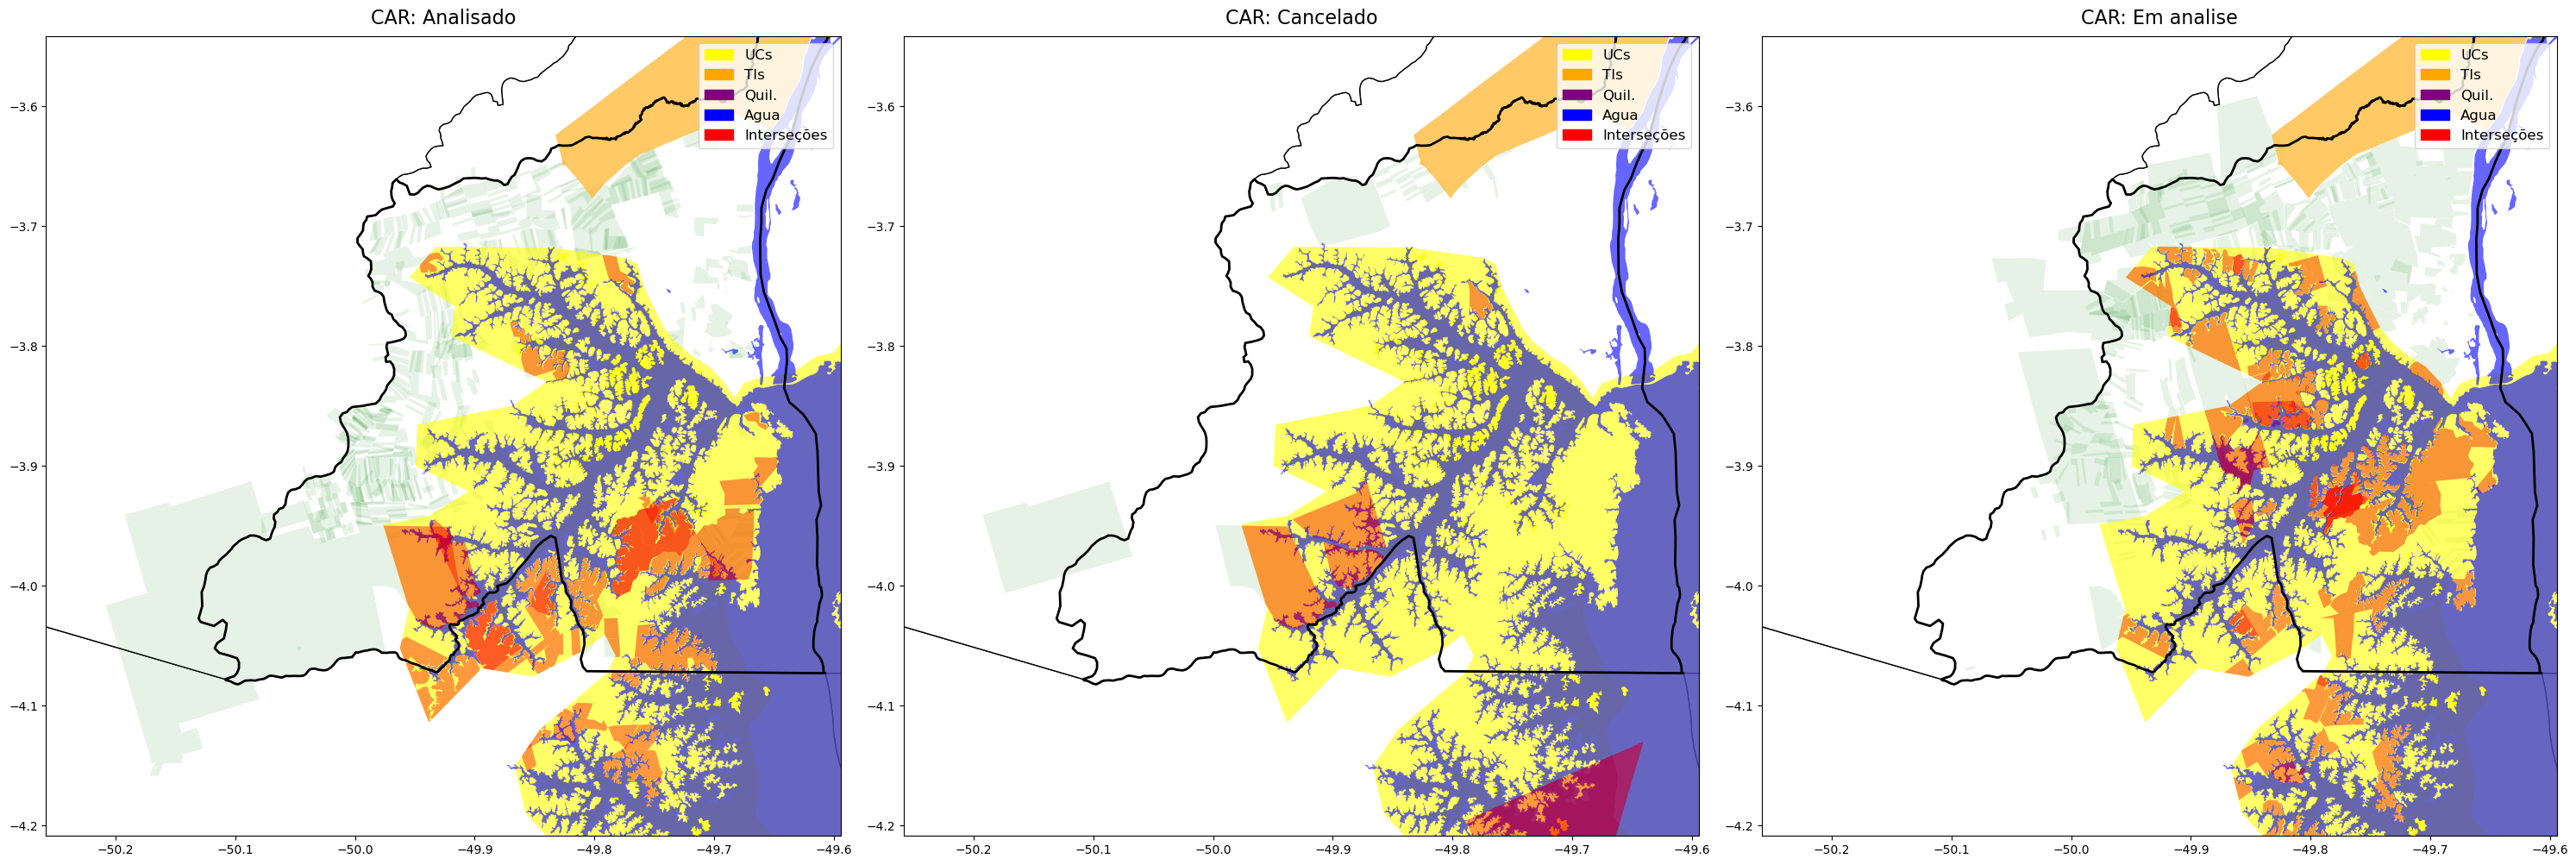

In [73]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

car = gdf  # Assuming car is the GeoDataFrame containing the CAR data

# Create a new column for condition description
car["desc_cond"] = car['des_condic'].apply(
    lambda x: "Analisado" if x.startswith("Analisado") else (
        "Cancelado" if x.startswith("Cancelado") else "Em analise"
    )
)

# Filter CAR data for Tucuruí (adjust if needed based on the correct column name)
tucurui_car = car[car['municipio'].str.contains('tucurui', case=False, na=False)]

# Coordinates for Tucuruí (get bounds of the filtered CAR data)
minx, miny, maxx, maxy = tucurui_car.total_bounds

# Define CAR categories
conditions = ['Analisado', 'Cancelado', 'Em analise']

# Create a subplot grid: 1 row and 3 columns (one for each condition)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(30, 16), dpi=100)

# Initialize a list for storing legend proxies
proxy_artists = []

# Loop through each condition and plot
for i, cond in enumerate(conditions):
    ax = axes[i]  # Access the subplot for the condition
    
    # Plot the base maps: States (uf) and Municipalities (municipios)
    uf.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)
    g_m.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)
    
    # Plot the filtered CAR data for the current condition
    condition_car = tucurui_car[tucurui_car['desc_cond'] == cond]  # Filter for the condition
    condition_car.plot(ax=ax, color='green', edgecolor='black', linewidth=0.00001, alpha=0.1)

    # Plot each dataset (dset) with corresponding colors
    for j, dset in enumerate(q_is):
        datasets[dset].plot(ax=ax, edgecolor='black', linewidth=0, color=cores[j], alpha=0.6)
        proxy = mpatches.Patch(color=cores[j], label=dset)  # Create a legend patch for this dataset
        proxy_artists.append(proxy)
    
        # Filter intersections based on the current condition
        condition_intersect = intersecting_gdfs[j][intersecting_gdfs[j]['des_condic'] == cond]
        condition_intersect.plot(ax=ax, color='red', edgecolor='black', linewidth=0.0001, alpha=0.4)
        i_proxy = mpatches.Patch(color='red', label='Interseções')  # Add a legend for intersections
    proxy_artists.append(i_proxy)

    # Plot the boundaries of Tucuruí with a darker color and thicker line
    tucurui = g_m[g_m['NM_MUN'].str.contains('tucuruí', case=False, na=False)]  # Filter Tucuruí from municipios
    tucurui.plot(ax=ax, edgecolor='black', linewidth=2, facecolor='none')  # Darker line for Tucuruí
    
    # Set title for each subplot (condition)
    ax.set_title(f"CAR: {cond}", fontsize=16, pad=10)
    
    # Set the limits for each subplot (centered around Tucuruí)
    ax.set_xlim(minx - 0.05, maxx + 0.05)
    ax.set_ylim(miny - 0.05, maxy + 0.05)
    
    # Add the legend to the plot for each subplot
    ax.legend(handles=proxy_artists, loc='upper right', fontsize=12)
    proxy_artists = []  
# Adjust the layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()

# Close the figure to free memory
plt.close()
